In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('D:/DEPI/Amit/Amit/machine_learning/In-Sessions/data_sets/Salary_Data.csv')
data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


<Figure size 300x300 with 0 Axes>

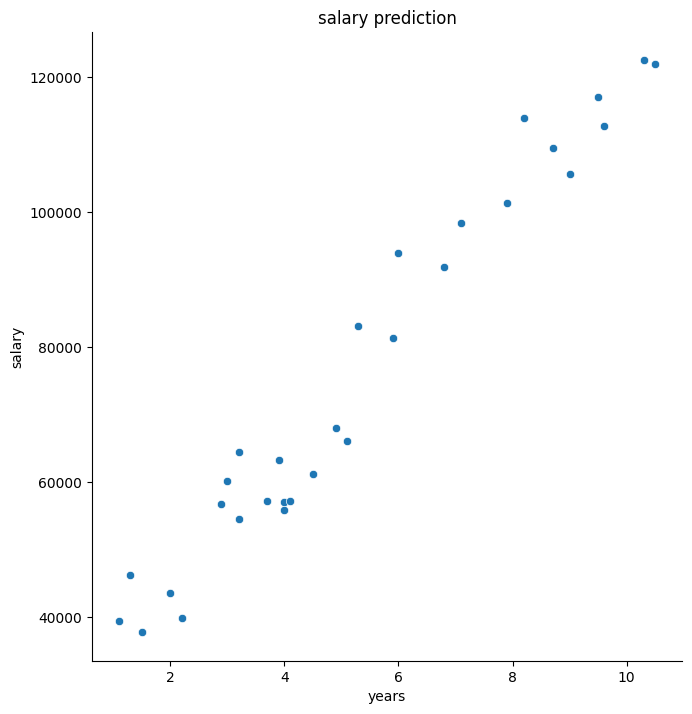

In [3]:
plt.figure(figsize=(3,3))
sns.pairplot(data,x_vars=["YearsExperience"],y_vars=["Salary"],size=7,kind="scatter")
plt.xlabel("years")
plt.ylabel("salary")
plt.title("salary prediction")
plt.show()

In [4]:
x = data.iloc[:,:-1]
y = data.iloc[:,1]

x_train,x_test,y_train,y_tast=train_test_split(x,y,train_size=0.8,random_state=52)

In [5]:
from sklearn.preprocessing import PolynomialFeatures

In [6]:
poly = PolynomialFeatures(degree=15)
x_poly_train = poly.fit_transform(x_train)
x_poly_test = poly.transform(x_test)
poly_model = LinearRegression()
poly_model.fit(x_poly_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
y_poly_pred_train = poly_model.predict(x_poly_train)
y_poly_pred_test = poly_model.predict(x_poly_test)

In [8]:
x_range = np.linspace(x.min(),x.max(),100).reshape(-1,1)
x_range_poly = poly.transform(x_range)
#print(x_range_poly)
y_range_pred = poly_model.predict(x_range_poly)
print(y_range_pred)

[ 39357.41175528  39649.31144462  40019.25413733  40475.60023863
  41024.66902862  41670.16096893  42412.68434421  43249.41964146
  44173.94704775  45176.25323504  46242.92376947  47357.51757129
  48501.11035579  49652.9853393   50791.44205985  51894.68822625
  52941.77527604  53913.53591742  54793.48139661  55568.61754255
  56230.14169628  56773.98727439  57201.18873402  57518.04684537
  57736.08215114  57871.77298942  57946.08315675  57983.79286626
  58012.65479671  58062.40443248  58163.6602897   58346.75477019
  58640.54008293  59071.21577184  59661.2247842   60428.26365876
  61384.44931689  62535.680161    63881.22285318  65413.54842502
  67118.43249023  68975.32455766  70957.98109007  73035.34634852
  75172.65459394  77332.71723485  79477.34942293  81568.88276434
  83571.70460939  85453.76012802  87187.95134687  88753.36779976
  90136.28653145  91330.88503361  92339.61932182  93173.23057365
  93850.35752106  94396.74774551  94844.0786438   95228.41795158
  95588.37314987  95962.9

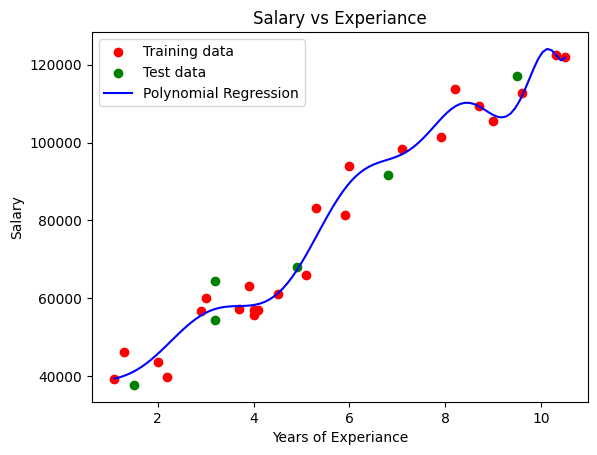

In [9]:
plt.scatter(x_train,y_train,color='red',label='Training data')
plt.scatter(x_test,y_tast,color='green',label='Test data')
plt.plot(x_range,y_range_pred,color='blue',label='Polynomial Regression')
plt.title('Salary vs Experiance')
plt.xlabel('Years of Experiance')
plt.ylabel('Salary')
plt.legend()
plt.show()

In [10]:
mse = mean_squared_error(y_tast,y_poly_pred_test)
print(mse)
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(y_tast,y_poly_pred_test)
print(rmse)
r2 = r2_score(y_tast,y_poly_pred_test)
print(r2)


23285947.111099925
4825.5514825872415
0.9647863127059144
